In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import torch

import care
import utils_plot

In [3]:
# --!--------------------------------------------------------------------------
# --! load trained models

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = torch.load('../../models/kalman/kind_sim.pt', weights_only=False)

model.eval()

detuning(
  (operator_sta): operator_sta(
    (enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=20, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=160, bias=True)
          (1): Identity()
        )
      )
    )
    (model): Linear(in_features=6, out_features=6, bias=False)
    (dec_mean): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=6, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=20, bias=True)
          (1): Identity()
        )
      )
    )
    (dec_var): fcnn(
      (net)

Parameter containing:
tensor([[ 0.1950, -0.4588,  0.2961, -0.5062,  0.6867, -0.1096],
        [-0.2769,  0.4684,  0.6155,  0.1528,  0.1133, -0.0285],
        [-0.3857,  0.0059,  0.0459, -0.5324, -0.1256, -0.1731],
        [ 0.3530,  0.5403,  0.2699,  0.1476,  0.3697,  0.0915],
        [ 0.0936, -0.5534,  0.3073, -0.2352,  0.2213, -0.0075],
        [-0.0181, -0.1508,  0.4922,  0.2681,  0.0194,  0.4376]])


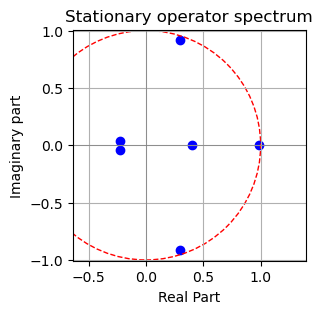

In [4]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

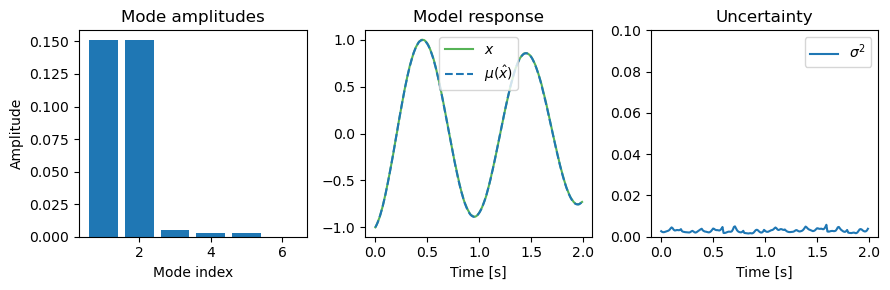

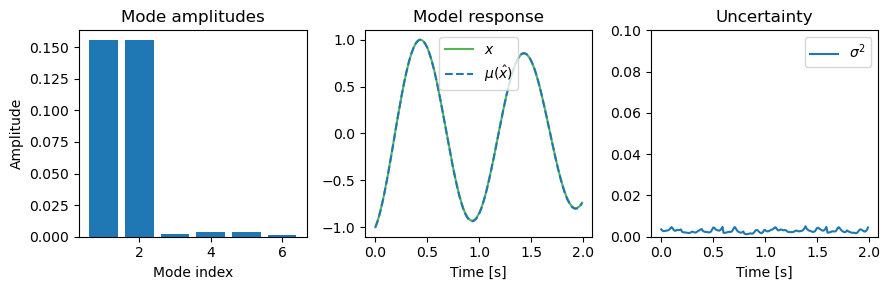

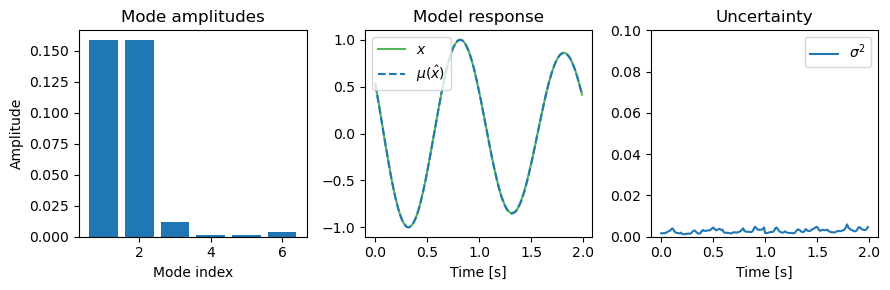

In [5]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = '../../data/kalman/train_sim_sta'
timeseries_nsample = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### KIND model test

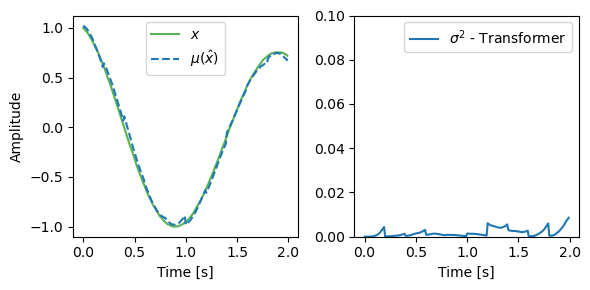

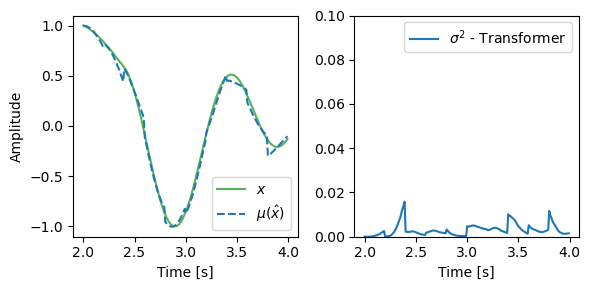

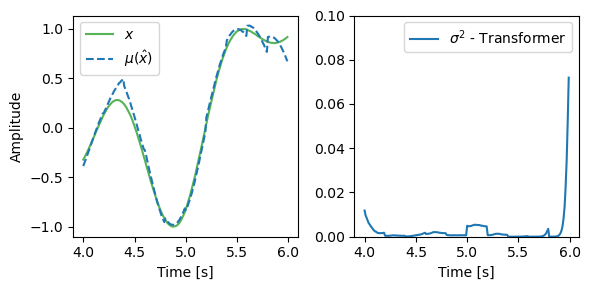

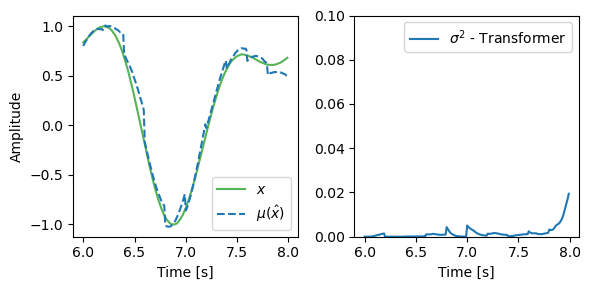

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a dynamic model

with torch.no_grad():
    datadir            = '../../data/kalman/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_transient(model, datadir, timeseries_nsample, datasaved=False)

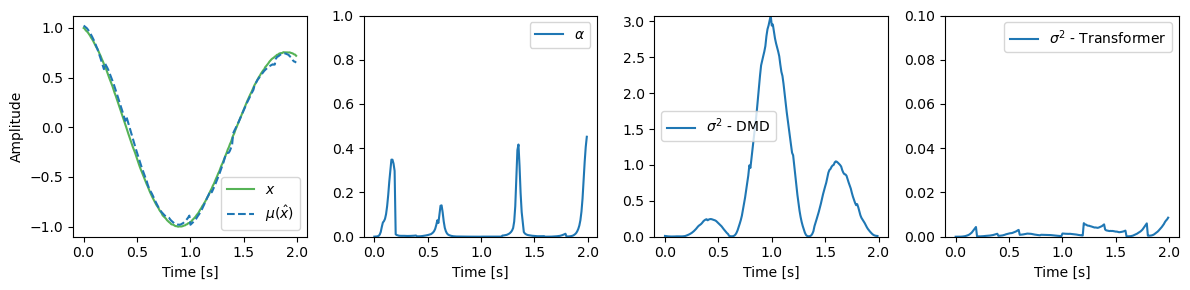

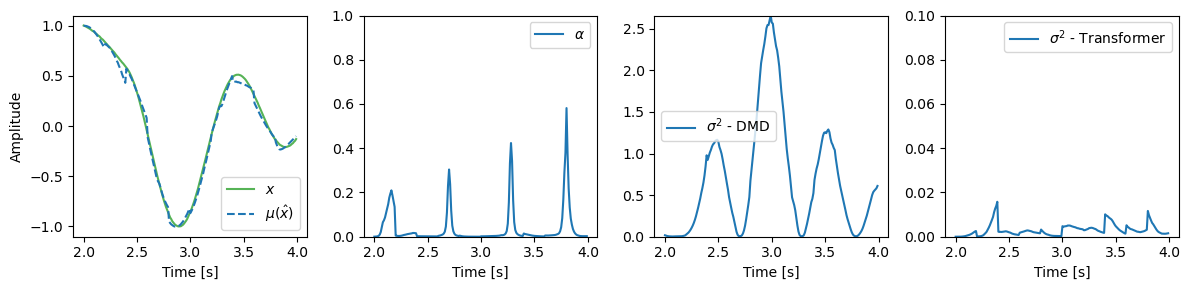

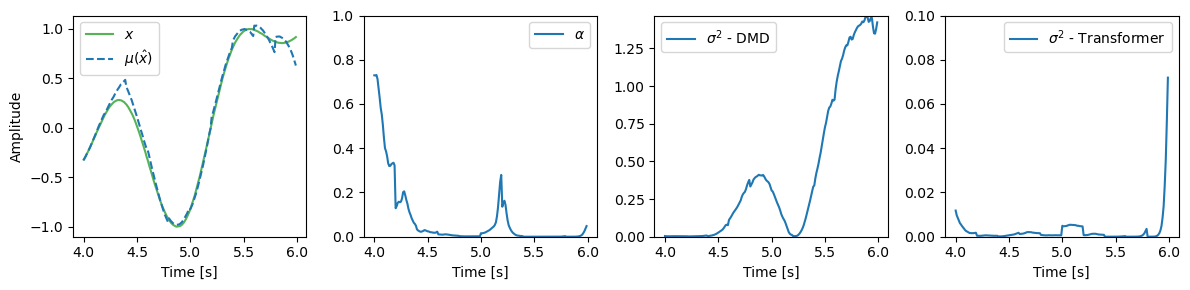

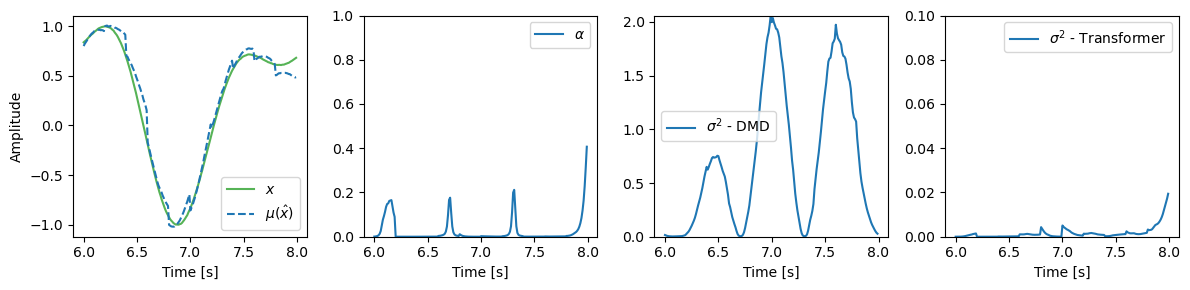

In [7]:
# --!--------------------------------------------------------------------------
# --! test alpha blending

with torch.no_grad():
    datadir            = '../../data/kalman/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_blend(model, datadir, timeseries_nsample, datasaved=False)